# MRI k-space Data Augmentation Visualization

이 노트북에서는 `utils/data/augmentation.py`의 augmentation 함수들을 사용하여 k-space 데이터의 augmentation 결과를 시각적으로 확인할 수 있습니다.

---

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
from utils.data.augmentation import augment_kspace, visualize_augmentation

# For reproducibility
np.random.seed(42)
torch.manual_seed(42)

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (augmentation.py, line 55)

In [ ]:
in_dir = "../Data/train/kspace/brain_acc4_1.h5"
kspace_f = h5py.File(in_dir)
kspace = kspace_f['kspace']
kspace = np.array(kspace)  # Convert to numpy array
print(f"kspace shape: {kspace.shape}")
print("kspace example:", kspace[0, 0, 0, 0])  # Example of a single k-space point

kspace = np.stack([kspace.real, kspace.imag], axis=-1)
print(f"kspace shape after stacking: {kspace.shape}")
kspace = torch.tensor(kspace, dtype=torch.float64)

kspace shape: (16, 16, 768, 396)
kspace example: (-4.305737e-06+1.0849908e-07j)
kspace shape after stacking: (16, 16, 768, 396, 2)


In [ ]:
# Define augmentation configuration
augment_config = {
    'flip': True,
    'flip_horizontal': True,
    'rotate90': True,
    'translate': True,
    'translate_max': 10,
    'affine': True,
    'affine_rot': 8,
    'affine_scale': 0.08,
    'affine_shear': 3
}
print("Augmentation config:", augment_config)

Augmentation config: {'flip': True, 'flip_horizontal': True, 'rotate90': True, 'translate': True, 'translate_max': 10, 'affine': True, 'affine_rot': 8, 'affine_scale': 0.08, 'affine_shear': 3}


In [ ]:
# Visualize original and augmented images for coil 0
visualize_augmentation(kspace, augment_config, coil_idx=0)

# Visualize all coils
visualize_augmentation(kspace, augment_config, coil_idx='all')

NameError: name 'visualize_augmentation' is not defined

Different augmentation config: {'flip': True, 'flip_horizontal': False, 'rotate90': False, 'translate': True, 'translate_max': 4, 'affine': True, 'affine_rot': 2, 'affine_scale': 0.02, 'affine_shear': 1}


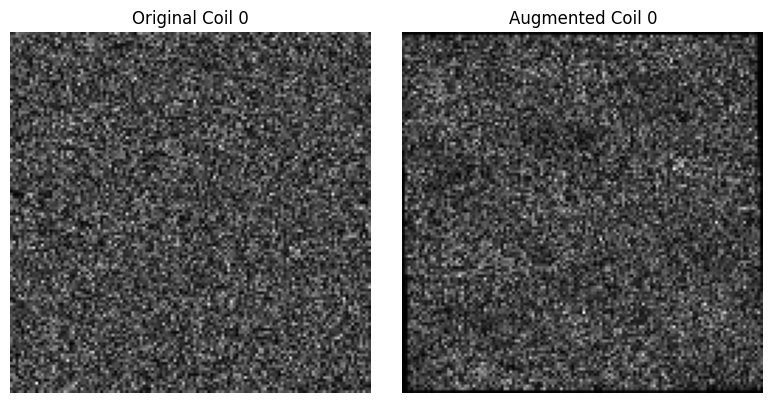

In [ ]:
# Try different augmentation settings
augment_config2 = {
    'flip': True,
    'flip_horizontal': False,
    'rotate90': False,
    'translate': True,
    'translate_max': 4,
    'affine': True,
    'affine_rot': 2,
    'affine_scale': 0.02,
    'affine_shear': 1
}
print("Different augmentation config:", augment_config2)
visualize_augmentation(kspace, augment_config2, coil_idx=0)